In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
#import seaborn as sns
from matplotlib.lines import Line2D
from sklearn import preprocessing
from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt
%matplotlib inline
import pickle
import math
import joblib

In [3]:
# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html#sklearn.ensemble.GradientBoostingClassifier.fit
# https://scikit-learn.org/stable/modules/ensemble.html#gradient-boosting
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
#from orphans.plotting_lc import plot_pseudo_obs
#from orphans.tools import pseudo_obs_with_points

In [4]:
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

### Load features

In [ ]:
df_orphans_ztf = pd.read_pickle('data/skysurvey/orphan_pseudo_obs_features_ztf.pkl')

In [6]:
df_orphans_ztf = df_orphans_ztf.drop(columns=['config', 'time', 'flux', 'flux_err', 'mags', 'filt', 'zp', 'mags_err', 'r-i'])

In [7]:
df_alerts_ztf = pd.read_pickle(f'data/skysurvey/ztf_alerts_lc_features.pkl')

In [8]:
df_alerts_ztf = df_alerts_ztf.drop(columns=['obj', 'time', 'mags', 'mags_err', 'filt', 'r-i'])

In [9]:
df_orphans_ztf['type'] = 'orphans'
df_alerts_ztf['type'] = 'background'

In [10]:
print(len(df_orphans_ztf), len(df_alerts_ztf))

1205 1009


In [11]:
df_ztf = pd.concat([df_orphans_ztf, df_alerts_ztf])

In [12]:
df_ztf.replace([np.inf, -np.inf], 1000, inplace=True)
df_ztf.fillna(0, inplace=True)
df_ztf

,duration,increase_rate,decrease_rate_1,decrease_rate_3,g-r,A,B,C,D,chi2,A/B,type
0,0.000000,0.000000,0.251654,0.016953,0.286740,-0.109682,23.482095,-5.906249,0.147696,1.923697,-0.004671,orphans
1,0.000000,-0.107713,0.021403,0.011514,-0.191514,-0.036952,21.310991,-2.446441,0.166137,0.798260,-0.001734,orphans
2,0.058594,-0.430262,0.227294,0.484602,0.063503,-0.009751,20.763799,-3.590199,0.247495,1.112860,-0.000470,orphans
3,0.000000,-0.027597,0.048661,0.117432,-0.064749,-0.053037,21.876911,-4.790637,0.156745,2.781244,-0.002424,orphans
4,0.000000,-0.052477,0.185058,0.081695,0.269028,0.201403,16.225479,-7.648668,4.122530,189.576321,0.012413,orphans
...,...,...,...,...,...,...,...,...,...,...,...,...
2610,7.958935,-0.007995,0.000000,0.000000,-0.031487,-0.076022,19.927954,-0.028800,5.589846,1.729788,-0.003815,background
2611,11.936724,-0.001831,0.015307,0.019257,1.151777,0.046569,17.338466,0.674386,7.254354,5.083257,0.002686,background
2613,0.000000,0.000000,0.000000,0.000000,0.379784,-0.000438,19.210466,-0.399166,9.999683,1.333201,-0.000023,background
2617,6.969595,-0.083817,0.000000,0.000000,0.078472,-0.027605,19.224090,0.359622,9.999646,1.431929,-0.001436,background


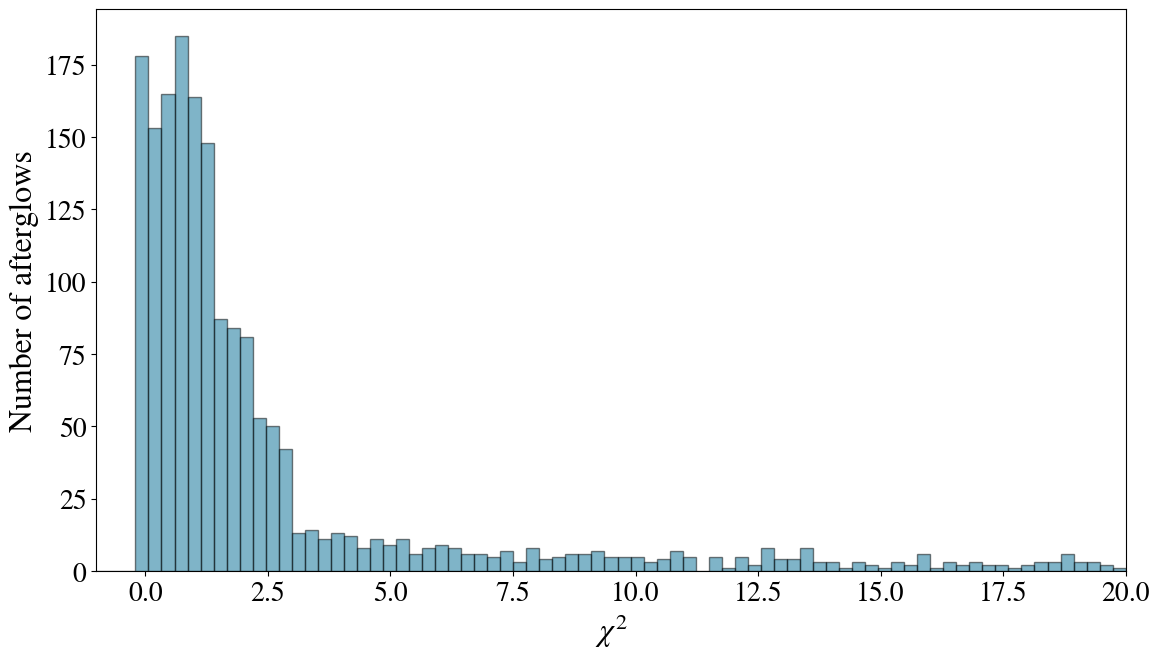

In [14]:
plt.rcParams.update({'font.size': 20})
plt.figure(figsize=(12, 7))

bin_edges = np.linspace(-1, 20, 80)
plt.hist(df_ztf['chi2'], bins=bin_edges, color='#006b93', alpha=0.5, edgecolor='black')
plt.xlabel(r"$\chi^2$", fontsize=23)
plt.ylabel("Number of afterglows", fontsize=23)
plt.xlim(-1, 20)

plt.tight_layout()

#plt.savefig("/home/masson/afterglowpy/figures/chi2_distrib_ztf.pdf", format="pdf", bbox_inches="tight", transparent=True)
plt.show()

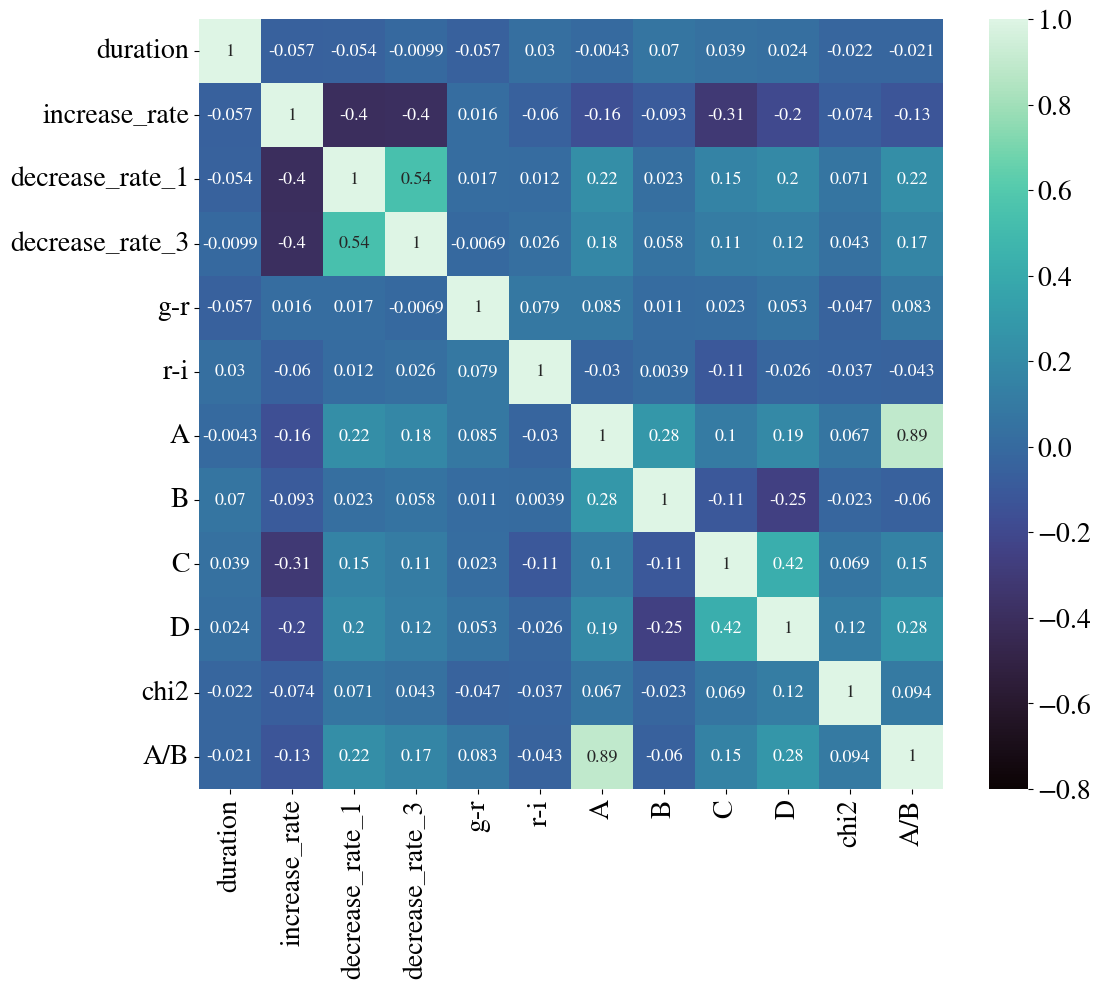

In [34]:
plt.rcParams.update({'font.size': 20})
fig, axes = plt.subplots(figsize=(12,10))

sns.heatmap(df_ztf.corr(), annot=True, cmap="mako", annot_kws={"fontsize":13}, vmin=-0.8)
#plt.savefig('/home/masson/afterglowpy/figures/ztf_features_correlations.pdf', format="pdf", bbox_inches="tight", transparent=True)

## Train classifier 

In [13]:
# create a sub dataframe with just elasticc data
bk_df = df_ztf[df_ztf['type']=='background']
bk_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1009 entries, 1 to 2620
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   duration         1009 non-null   float64
 1   increase_rate    1009 non-null   float64
 2   decrease_rate_1  1009 non-null   float64
 3   decrease_rate_3  1009 non-null   float64
 4   g-r              1009 non-null   float64
 5   A                1009 non-null   float64
 6   B                1009 non-null   float64
 7   C                1009 non-null   float64
 8   D                1009 non-null   float64
 9   chi2             1009 non-null   float64
 10  A/B              1009 non-null   float64
 11  type             1009 non-null   object 
dtypes: float64(11), object(1)
memory usage: 102.5+ KB


In [14]:
# create a sub dataframe with just orphans data
oa_df = df_ztf[df_ztf['type']=='orphans']
oa_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1205 entries, 0 to 1204
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   duration         1205 non-null   float64
 1   increase_rate    1205 non-null   float64
 2   decrease_rate_1  1205 non-null   float64
 3   decrease_rate_3  1205 non-null   float64
 4   g-r              1205 non-null   float64
 5   A                1205 non-null   float64
 6   B                1205 non-null   float64
 7   C                1205 non-null   float64
 8   D                1205 non-null   float64
 9   chi2             1205 non-null   float64
 10  A/B              1205 non-null   float64
 11  type             1205 non-null   object 
dtypes: float64(11), object(1)
memory usage: 122.4+ KB


In [15]:
# creating training and testing samples of elasticc data
bk_df_train = bk_df[:500].drop(columns=['type'])
bk_df_test = bk_df[500:].drop(columns=['type'])
bk_df_train.info()
bk_y_train = bk_df[:500]['type']
bk_y_test = bk_df[500:]['type']
bk_y_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 1 to 1233
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   duration         500 non-null    float64
 1   increase_rate    500 non-null    float64
 2   decrease_rate_1  500 non-null    float64
 3   decrease_rate_3  500 non-null    float64
 4   g-r              500 non-null    float64
 5   A                500 non-null    float64
 6   B                500 non-null    float64
 7   C                500 non-null    float64
 8   D                500 non-null    float64
 9   chi2             500 non-null    float64
 10  A/B              500 non-null    float64
dtypes: float64(11)
memory usage: 46.9 KB
<class 'pandas.core.series.Series'>
Index: 509 entries, 1234 to 2620
Series name: type
Non-Null Count  Dtype 
--------------  ----- 
509 non-null    object
dtypes: object(1)
memory usage: 8.0+ KB


In [16]:
# creating training and testing samples of orphan afterglows
oa_df_train = oa_df[:500].drop(columns=['type'])
oa_df_test = oa_df[500:].drop(columns=['type'])
oa_df_train.info()
oa_y_train = oa_df[:500]['type']
oa_y_test = oa_df[500:]['type']
oa_y_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   duration         500 non-null    float64
 1   increase_rate    500 non-null    float64
 2   decrease_rate_1  500 non-null    float64
 3   decrease_rate_3  500 non-null    float64
 4   g-r              500 non-null    float64
 5   A                500 non-null    float64
 6   B                500 non-null    float64
 7   C                500 non-null    float64
 8   D                500 non-null    float64
 9   chi2             500 non-null    float64
 10  A/B              500 non-null    float64
dtypes: float64(11)
memory usage: 46.9 KB
<class 'pandas.core.series.Series'>
Index: 705 entries, 500 to 1204
Series name: type
Non-Null Count  Dtype 
--------------  ----- 
705 non-null    object
dtypes: object(1)
memory usage: 11.0+ KB


In [17]:
# create training and testing samples
X_train = pd.concat([bk_df_train, oa_df_train])
X_test = pd.concat([bk_df_test, oa_df_test])
y_train = pd.concat([bk_y_train, oa_y_train])
y_test = pd.concat([bk_y_test, oa_y_test])

In [18]:
# normalise the features
X_train_n = preprocessing.normalize(X_train, norm='max')
X_test_n = preprocessing.normalize(X_test, norm='max')

In [19]:
clf = GradientBoostingClassifier(n_estimators=175, learning_rate=0.1,
                                 max_depth=5, random_state=0).fit(X_train_n, y_train)

In [20]:
clf.score(X_test_n, y_test)

0.9719934102141681

Text(0, 0.5, 'loss')

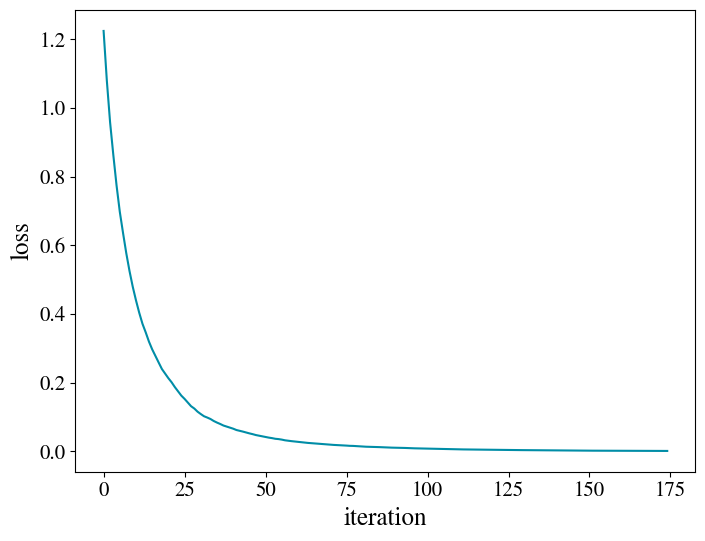

In [21]:
plt.figure(figsize=(8, 6))
plt.rcParams.update({'font.size': 15})

plt.plot(clf.train_score_, color='#008da7')
plt.xlabel('iteration', fontsize=18)
plt.ylabel('loss', fontsize=18)

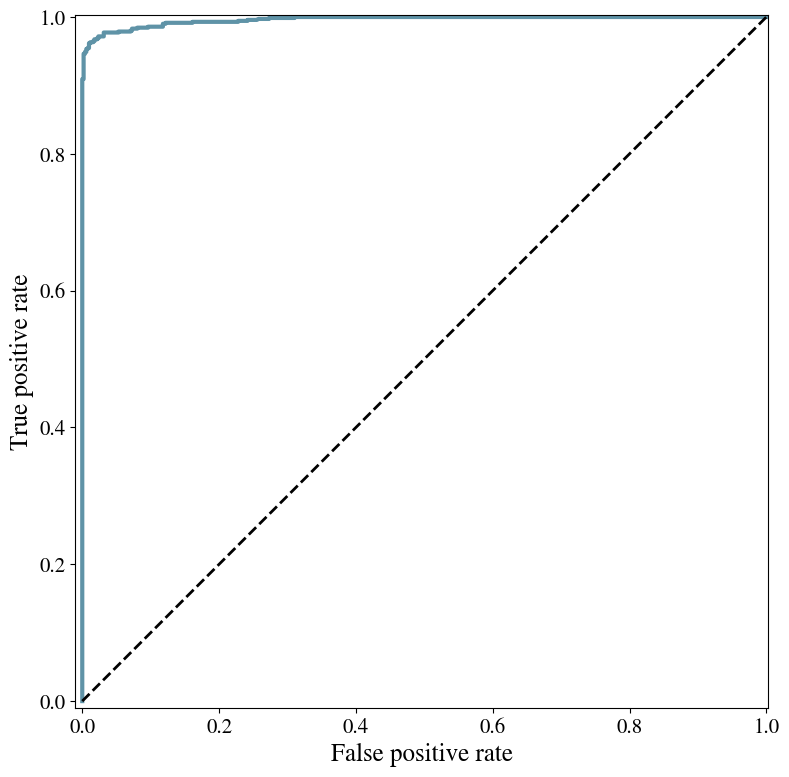

In [22]:
from sklearn.metrics import RocCurveDisplay

plt.rcParams.update({'font.size': 15})

x = np.linspace(0., 1., 100)
y = np.linspace(0., 1., 100)

fig, ax = plt.subplots(figsize=(9, 9))

RocCurveDisplay.from_estimator(clf, X_test_n, y_test, ax=ax, color="#5f93a7", lw=3)
plt.plot(x, y, color='k', lw=2., ls='--', label='random')
ax.set_xlabel('False positive rate', fontsize=18)
ax.set_ylabel('True positive rate', fontsize=18)
ax.set_xlim(-0.01, 1.003)
ax.legend_.remove()
ax.set_ylim(-0.01, 1.003)

#plt.savefig('../figures/roc_curve.pdf', transparent=True, bbox_inches='tight')

plt.show()

## Confusion matrix

In [23]:
y_pred = clf.predict(X_test)

/home/masson/anaconda3/envs/afterglowpy/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(


In [24]:
threshold = 0.95
y_pred_bool = np.array(clf.predict_proba(X_test_n)[:, 1] >= threshold)

y_pred= []
for y in y_pred_bool:
    if y == True:
        y_pred.append('orphans')
    elif y == False:
        y_pred.append('background')
    else:
        print(y)

In [25]:
proba=clf.predict_proba(X_test_n)

Text(0, 0.5, 'True label')

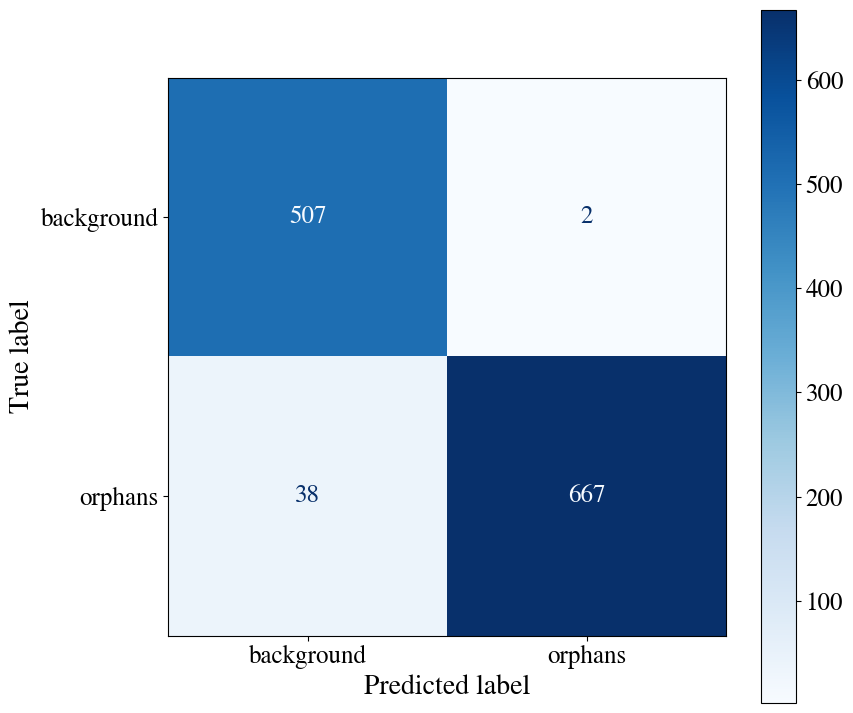

In [26]:
plt.rcParams["figure.figsize"] = [9, 9]
plt.rcParams["font.size"] = 18

disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                                              display_labels=['background', 'orphans'],
                                              cmap=plt.cm.Blues)

plt.xlabel('Predicted label', fontsize=20)
plt.ylabel('True label', fontsize=20)

#plt.savefig('/home/masson/afterglowpy/figures/confusion_matrix_095_ztf.pdf', transparent=True, bbox_inches='tight')

In [27]:
X_test_proba = X_test
X_test_proba['proba_orphans'] = proba[:,1]
X_test_proba['type'] = y_test

In [28]:
X_test_proba_orphan = X_test_proba[X_test_proba['proba_orphans'] > 0.95]

In [29]:
X_test_proba_orphan

,duration,increase_rate,decrease_rate_1,decrease_rate_3,g-r,A,B,C,D,chi2,A/B,proba_orphans,type
1978,1.007581,-0.027955,0.033685,0.021614,0.000000,0.046825,19.210723,-0.608738,0.000336,1.342022,0.002437,0.950591,background
2270,4.144907,-0.016535,0.013349,0.003374,-0.006690,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.993316,background
500,0.011719,0.000000,0.043429,0.055509,0.073679,0.032296,19.380066,-2.671292,0.201778,1.670587,0.001666,0.999879,orphans
501,0.000000,-0.005661,0.000000,0.000000,0.252539,0.004409,20.382993,-2.922779,1.279448,0.188640,0.000216,0.997380,orphans
503,1.062500,-0.171992,0.185110,0.075953,-0.054960,-0.009617,20.818633,-4.844611,0.417581,1.241484,-0.000462,0.999982,orphans
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1199,3.003906,-0.196594,0.051360,0.026945,0.000000,0.127483,17.466687,16224.909821,8.725389,11.853623,0.007299,0.999901,orphans
1200,0.000000,-0.007090,0.073580,0.037042,0.194997,0.032584,16.860841,-1.679174,0.129231,2.037210,0.001933,0.999801,orphans
1201,0.933594,-0.233045,0.155305,0.087042,-1.075178,0.120602,15.803981,72556.004923,10.000000,624.029154,0.007631,0.999901,orphans
1202,0.000000,-0.055846,0.098374,0.037370,-0.035699,-0.016296,21.080030,-2.560691,0.177678,0.793548,-0.000773,0.999966,orphans


In [30]:
ztf_classified_orphans = pd.merge(X_test_proba_orphan[X_test_proba_orphan['type']=='background'], 
                                       df_ztf[df_ztf['type']=='background'], on=['duration', 'increase_rate',
                                                                                         'decrease_rate_1', 'decrease_rate_3',
                                                                                         'g-r', 'A', 'B', 'C', 'D', 'chi2'], 
                                       suffixes=('', '_y'), how = 'left')

ztf_classified_orphans = ztf_classified_orphans.drop(columns=['A/B_y', 'type_y'])

In [31]:
ztf_classified_orphans

,duration,increase_rate,decrease_rate_1,decrease_rate_3,g-r,A,B,C,D,chi2,A/B,proba_orphans,type
0,1.007581,-0.027955,0.033685,0.021614,0.00000,0.046825,19.210723,-0.608738,0.000336,1.342022,0.002437,0.950591,background
1,4.144907,-0.016535,0.013349,0.003374,-0.00669,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.993316,background


In [32]:
alertId = df_ztf[(df_ztf['type']=='background') & (df_ztf['chi2']==ztf_classified_orphans.iloc[0]['chi2'])]['alertId']

NameError: name 'chi2' is not defined

In [33]:
df_ztf_lc = pd.read_pickle('data/skysurvey/ztf_alerts_lc_features.pkl')

In [34]:
df_ztf_lc

,obj,time,mags,mags_err,filt,duration,g-r,r-i,A,B,C,D,chi2,increase_rate,decrease_rate_1,decrease_rate_3,A/B
1,ZTF25aaqkrze,"[2460820.9389005, 2460820.891956, 2460826.9020...","[18.816198348999023, 18.937110900878906, 19.03...","[0.06286535412073135, 0.06951691955327988, 0.1...","[r, g, g, g, r, r, r, r, g, r, g, g, g, r, g, ...",0.000000,-0.226037,NaN,0.049588,18.450465,0.593330,0.353259,1.424129,-0.007099,0.002716,0.009636,0.002688
2,ZTF25aaqemtu,"[2460817.8029977, 2460814.7914352, 2460821.773...","[19.547832489013672, 19.639507293701172, 19.32...","[0.11139839142560959, 0.2130787968635559, 0.11...","[g, g, g, g, g, g]",6.982419,NaN,NaN,-0.010103,19.428526,-0.092746,-0.000717,1.421440,-0.007585,0.000000,0.000000,-0.000520
6,ZTF25aasbffv,"[2460842.6939699, 2460851.6742593, 2460845.755...","[18.785743713378906, 19.200807571411133, 18.91...","[0.08912719786167145, 0.15062417089939117, 0.1...","[r, r, r, g, r, g, r, r, r, g, g, r, g, g, g, ...",6.001875,-0.145575,NaN,0.056289,17.976253,0.673255,1.210572,0.730038,-0.008419,0.018036,0.011979,0.003131
7,ZTF25aaglicm,"[2460796.7960301, 2460798.7935185, 2460816.772...","[19.759605407714844, 19.80546760559082, 20.003...","[0.10664847493171692, 0.15873266756534576, 0.1...","[r, r, r, r, r]",0.000000,NaN,NaN,0.008049,19.806140,-0.046366,0.509540,NaN,-0.000244,0.000000,0.000000,0.000406
9,ZTF25aarxyue,"[2460832.8616898, 2460850.8574653, 2460832.793...","[18.66661834716797, 19.594676971435547, 18.827...","[0.1356334239244461, 0.12517870962619781, 0.09...","[g, r, r, r, g, r, g, g, g, r, g, g, r, g, r]",0.000000,-0.030313,NaN,0.084806,17.044940,2.182148,0.087890,1.259623,0.000000,0.001775,0.012473,0.004975
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2610,ZTF25aavspfv,"[2460853.8414352, 2460851.8365509, 2460849.775...","[19.54403305053711, 19.643844604492188, 19.896...","[0.11216419190168381, 0.1356380432844162, 0.14...","[r, r, r, r, g, r, r, g, g]",7.958935,-0.031487,NaN,-0.076022,19.927954,-0.028800,5.589846,1.729788,-0.007995,0.000000,0.000000,-0.003815
2611,ZTF25aasfkmy,"[2460850.9363542, 2460834.960625, 2460844.9000...","[18.45162010192871, 17.76874542236328, 18.3339...","[0.06707126647233963, 0.028205329552292824, 0....","[r, r, r, g, r, g, r, g, g, g, g, r, g, g, r, ...",11.936724,1.151777,NaN,0.046569,17.338466,0.674386,7.254354,5.083257,-0.001831,0.015307,0.019257,0.002686
2613,ZTF25aapqqjw,"[2460820.6820949, 2460815.6816319, 2460822.753...","[19.57213020324707, 19.29234504699707, 19.3618...","[0.1750354766845703, 0.1262696087360382, 0.159...","[g, g, g, g, r, g]",0.000000,0.379784,NaN,-0.000438,19.210466,-0.399166,9.999683,1.333201,0.000000,0.000000,0.000000,-0.000023
2617,ZTF25aavhnve,"[2460848.7946528, 2460847.8188194, 2460848.836...","[19.16620445251465, 19.065298080444336, 19.239...","[0.08856041729450226, 0.11144764721393585, 0.0...","[r, r, g, g, r, r, g, r, r, r, r, r, g, r, g, ...",6.969595,0.078472,NaN,-0.027605,19.224090,0.359622,9.999646,1.431929,-0.083817,0.000000,0.000000,-0.001436


In [37]:
obj_name = df_ztf_lc[df_ztf_lc['increase_rate']==ztf_classified_orphans.iloc[0]['increase_rate']]['obj']

In [38]:
obj_name

1978    ZTF25aaqqjxs
Name: obj, dtype: object

In [113]:
obj

,obj,time,mags,mags_err,filt,duration,g-r,r-i,A,B,C,D,chi2,increase_rate,decrease_rate_1,decrease_rate_3,A/B
2270,ZTF25aauztwy,"[2460850.8242245, 2460844.8478009, 2460846.858...","[20.219865798950195, 20.08644676208496, 20.247...","[0.15736664831638336, 0.16704300045967102, 0.2...","[r, r, r, g, r, r, r, r, g, g]",4.144907,-0.00669,NaN,NaN,NaN,NaN,NaN,NaN,-0.016535,0.013349,0.003374,NaN


In [91]:
obj.iloc[0]['time']

array([2460817.9735764, 2460818.9773264, 2460818.9811574, 2460819.976088 ,
       2460817.977419 , 2460821.9756944, 2460819.9803704, 2460817.9812616,
       2460818.9734838, 2460821.9795023])

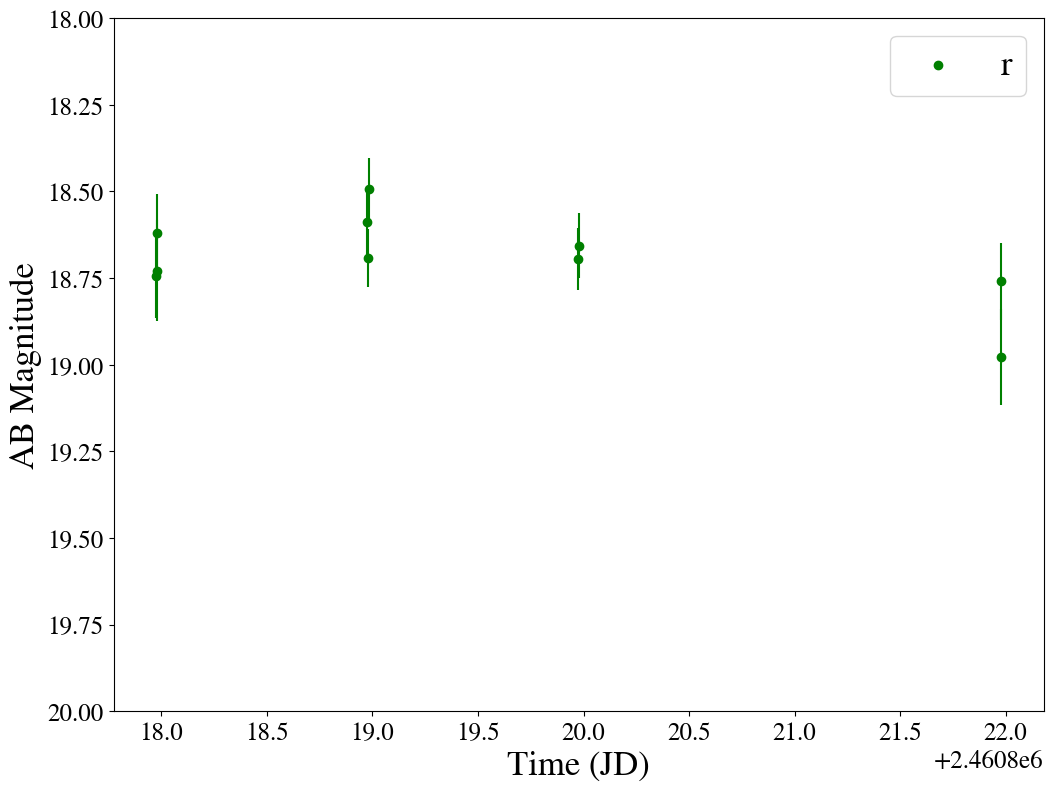

In [44]:
obj = df_ztf_lc[df_ztf_lc['obj']=='ZTF25aaqqjxs']

filter_colours = {'g':'c', 'r':'g', 'i':'orange'}


plt.rcParams["figure.figsize"] = [12, 9]
plt.rcParams["font.size"] = 18

for t, m, e, z in zip(obj.iloc[0]['time'], obj.iloc[0]['mags'], obj.iloc[0]['mags_err'], obj.iloc[0]['filt']):
    if t==obj.iloc[0]['time'][0]:
        plt.scatter(t, m, c=filter_colours[z], label='r')
    elif t==obj.iloc[0]['time'][3]:
        #plt.scatter(t, m, c=filter_colours[z], label='g')
        plt.scatter(t, m, c=filter_colours[z])
    else:
        plt.scatter(t, m, c=filter_colours[z])
    plt.errorbar(t, m, e, c=filter_colours[z])

plt.legend(fontsize=25)
plt.ylim(20, 18)
plt.xlabel('Time (JD)', fontsize=25)
plt.ylabel('AB Magnitude', fontsize=25)

#plt.savefig('/home/masson/afterglowpy/figures/ztf_alert_classified_orphan_ZTF25aaqqjxs.png', transparent=True, bbox_inches='tight')

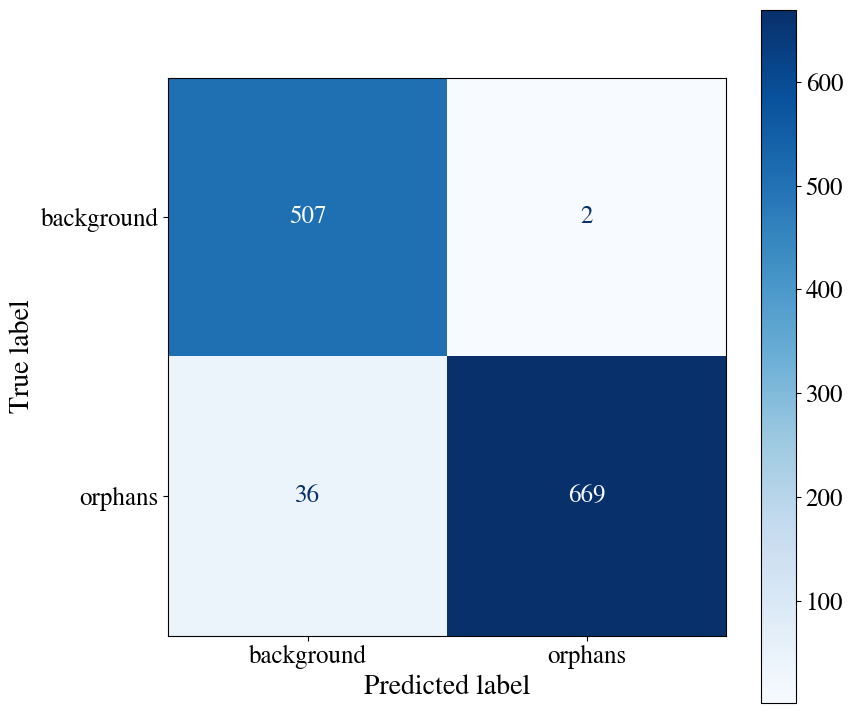

In [49]:
plt.rcParams["figure.figsize"] = [9, 9]
plt.rcParams["font.size"] = 18

disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                                              display_labels=['background', 'orphans'],
                                              cmap=plt.cm.Blues)

plt.xlabel('Predicted label', fontsize=20)
plt.ylabel('True label', fontsize=20)

#plt.savefig('/home/masson/afterglowpy/figures/confusion_matrix_095_ztf.pdf', transparent=True, bbox_inches='tight')

In [32]:
result = permutation_importance(clf, X_test_n, y_test, n_repeats=10,
                                random_state=0)

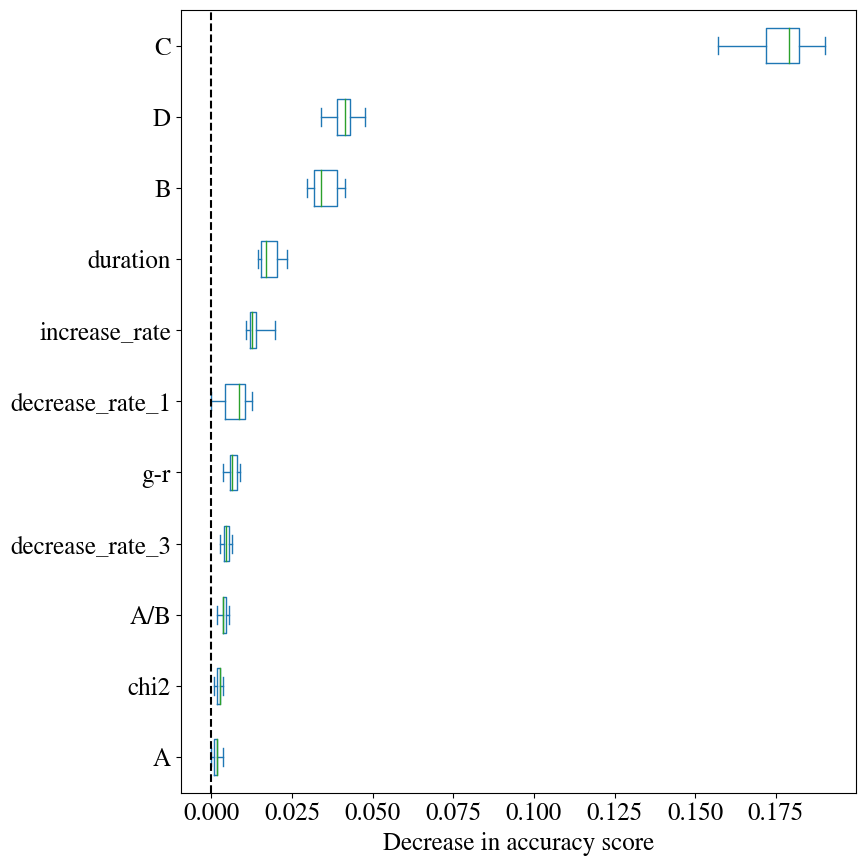

In [34]:
plt.rcParams.update({'font.size': 18})

sorted_importances_idx = result.importances_mean.argsort()
importances = pd.DataFrame(result.importances[sorted_importances_idx].T, 
                           columns=X_test.columns[sorted_importances_idx])

fig, ax = plt.subplots(1,1,figsize=(9,9))
importances.plot.box(vert=False, ax=ax, whis=10)
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()

#plt.savefig('/home/masson/afterglowpy/figures/features_importance_ztf.pdf', transparent=True, bbox_inches='tight')

plt.show()

## Test without retraining

In [21]:
df_ztf_norm = preprocessing.normalize(df_ztf, norm='max')

In [22]:
#clf = joblib.load('data/skysurvey/ml_model_orphans.pkl')
clf = joblib.load('data/ml_model_orphans_mags_variability.pkl')

In [23]:
pred = clf.predict(df_ztf_norm)

Text(0, 0.5, 'True label')

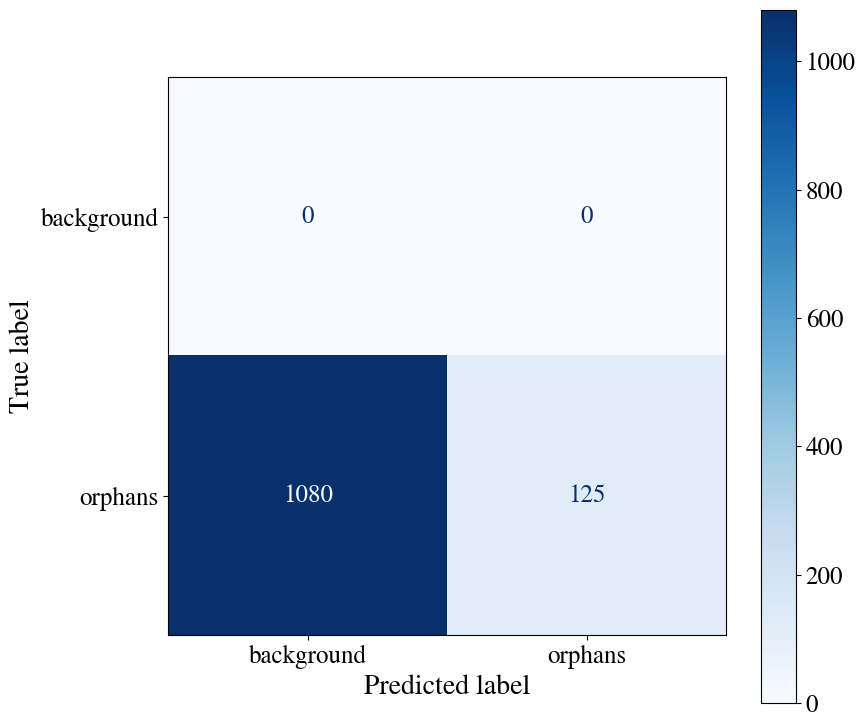

In [29]:
threshold = 0.999
y_pred_bool = np.array(clf.predict_proba(df_ztf_norm)[:, 1] >= threshold)
y_test = np.array(['orphans']*len(df_ztf))

y_pred= []
for y in y_pred_bool:
    if y == True:
        y_pred.append('orphans')
    elif y == False:
        y_pred.append('elasticc')
    else:
        print(y)


plt.rcParams["figure.figsize"] = [9, 9]
plt.rcParams["font.size"] = 18

disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                                              display_labels=['background', 'orphans'],
                                              cmap=plt.cm.Blues)

plt.xlabel('Predicted label', fontsize=20)
plt.ylabel('True label', fontsize=20)

#plt.savefig("/home/masson/afterglowpy/figures/ztf_confu_matrix.pdf", format="pdf", bbox_inches="tight", transparent=True)